# Funciones de Loop

## $\gamma \gamma$

--- Generando Plots de Diagnóstico ---


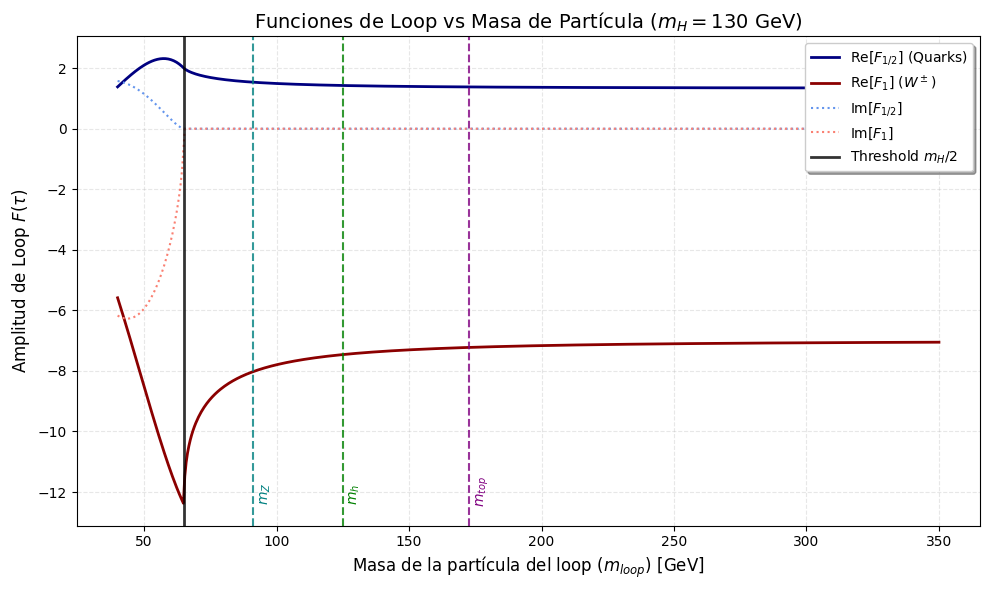

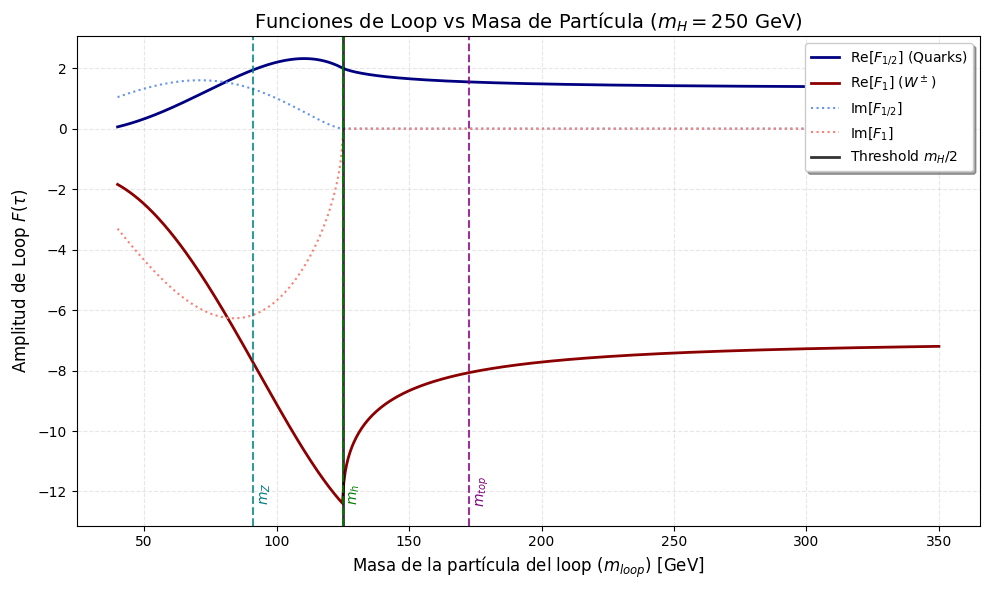

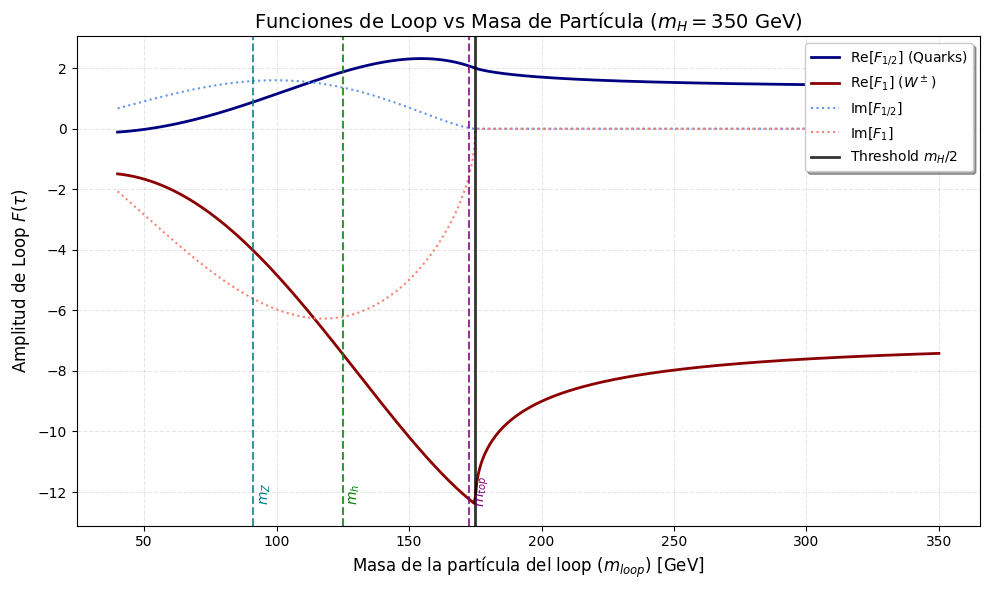

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONSTANTES FÍSICAS (Reference) ---
# Masas en GeV
m_top = 172.76
m_bottom = 4.18
m_h = 125
m_Z = 91.1876

# --- 2. FUNCIONES DE LOOP (CORE PHYSICS) ---
def tau_val(m_H, m_loop):
    """Definición de tau: tau = mH^2 / (4*m_loop^2)"""
    return (m_H**2) / (4 * m_loop_sq(m_loop) + 1e-9)

def m_loop_sq(m_loop):
    """Helper para manejar arrays de forma segura"""
    return m_loop**2

def f_func(tau):
    """Función escalar de loop f(tau) - Unitary Safe"""
    if tau <= 1:
        return np.arcsin(np.sqrt(tau))**2
    else:
        sqrt_term = np.sqrt(1 - 1/tau)
        ln_term = np.log((1 + sqrt_term) / (1 - sqrt_term))
        val = -0.25 * (ln_term - 1j * np.pi)**2
        return val

f_func_vec = np.vectorize(f_func)

def F_half(tau):
    """Spin 1/2 (Fermiones: Top, Bottom)"""
    ff = f_func_vec(tau)
    return 2 * (tau + (tau - 1) * ff) / (tau**2)

def F_one(tau):
    """Spin 1 (Bosones: W)"""
    ff = f_func_vec(tau)
    return - (2*tau**2 + 3*tau + 3*(2*tau - 1)*ff) / (tau**2)

# --- 3. PLOTTER AVANZADO CON MARCADORES DE MASA ---
def plot_m_ref_F_values(mH_ref):
    # Ajustamos el rango para ver desde el W hasta más allá del Top
    # Rango [40, 350] cubre W, Z, Top y la región asintótica
    m_loop_scan = np.linspace(40, 350, 600) 
    
    taus = tau_val(mH_ref, m_loop_scan)
    F12_vals = F_half(taus)
    F1_vals  = F_one(taus)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Curvas Principales
    ax.plot(m_loop_scan, np.real(F12_vals), label=r'Re[$F_{1/2}$] (Quarks)', color='navy', linewidth=2)
    ax.plot(m_loop_scan, np.real(F1_vals),  label=r'Re[$F_{1}$] ($W^\pm$)', color='darkred', linewidth=2)
    
    # Parte Imaginaria (Solo visible si m_loop < mH/2)
    ax.plot(m_loop_scan, np.imag(F12_vals), label=r'Im[$F_{1/2}$]', color='cornflowerblue', linestyle=':', linewidth=1.5)
    ax.plot(m_loop_scan, np.imag(F1_vals),  label=r'Im[$F_{1}$]', color='salmon', linestyle=':', linewidth=1.5)

    # --- VISUAL AID: MASAS FÍSICAS ---
    # Diccionario de partículas relevantes en este rango de energía
    particle_marks = {
        'h':  (m_h, 'green'),
        'Z':  (m_Z, 'teal'),
        'top': (m_top, 'purple')
        # Bottom está en 4 GeV, muy a la izquierda (asintótico)
    }

    # Umbral Cinemático del Higgs (mH/2)
    threshold = mH_ref / 2.0
    ax.axvline(x=threshold, color='black', linestyle='-', linewidth=2, alpha=0.8, label=r'Threshold $m_H/2$')

    # Pintar lineas de partículas
    y_min, y_max = ax.get_ylim()
    for p_name, (mass, color) in particle_marks.items():
        if min(m_loop_scan) < mass < max(m_loop_scan):
            ax.axvline(x=mass, color=color, linestyle='--', linewidth=1.5, alpha=0.8)
            # Etiqueta rotada para que no moleste
            ax.text(mass + 2, y_min + (y_max-y_min)*0.05, f'$m_{{{p_name}}}$', color=color, rotation=90, fontweight='bold')

    # Estética "Paper Quality"
    ax.set_title(r'Funciones de Loop vs Masa de Partícula ($m_H = ' + f'{mH_ref}$ GeV)', fontsize=14)
    ax.set_xlabel(r'Masa de la partícula del loop ($m_{loop}$) [GeV]', fontsize=12)
    ax.set_ylabel(r'Amplitud de Loop $F(\tau)$', fontsize=12)
    ax.legend(loc='upper right', frameon=True, shadow=True)
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- 4. EJECUCIÓN ---
print("--- Generando Plots de Diagnóstico ---")
# Caso 1: Higgs Ligero (SM-like, pero masa cambiada para test)
plot_m_ref_F_values(mH_ref=130)

# Caso 2: Higgs Pesado (Umbral cerca del top)
# Aquí mH/2 = 125 GeV. El Top (173) está A LA DERECHA del umbral.
# Por tanto, el loop de top NO tiene parte imaginaria.
plot_m_ref_F_values(mH_ref=250)

# Caso 3: Higgs Muy Pesado (Apertura de canal tt)
# Aquí mH/2 = 175 GeV. El Top (173) está A LA IZQUIERDA (por poco).
# Deberíamos ver aparecer la parte imaginaria justo sobre el top.
plot_m_ref_F_values(mH_ref=350)

Generando trazas para los 6 quarks...


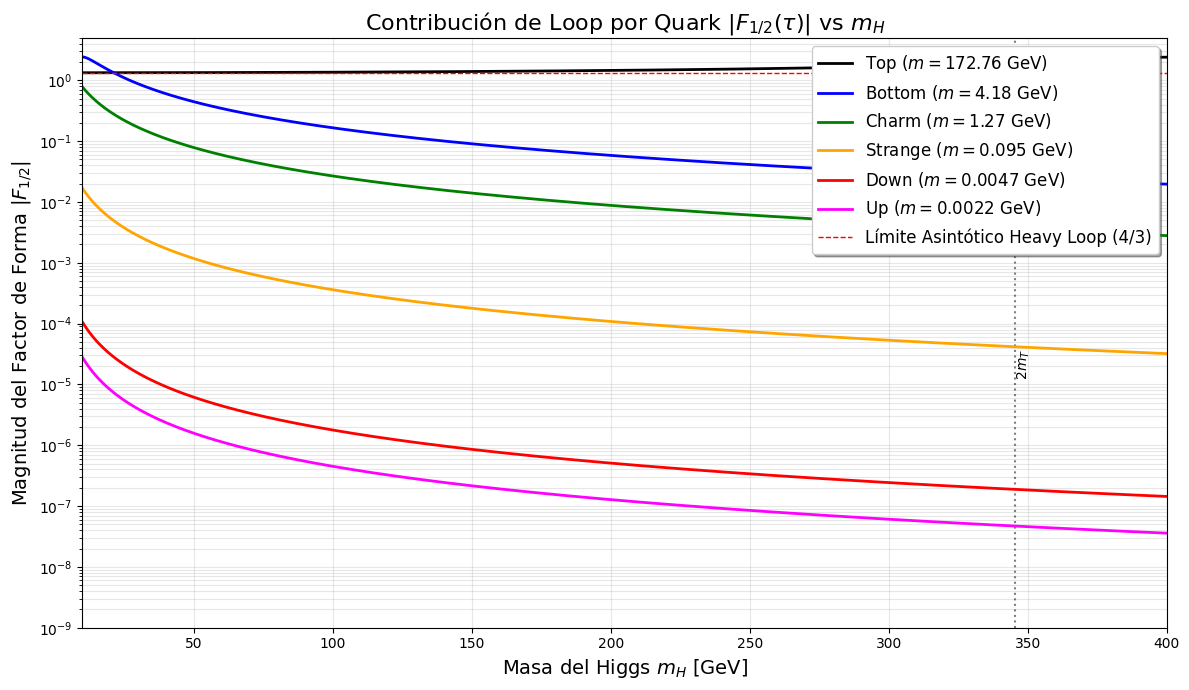


--- Valores Puntuales (Benchmark mH = 400 GeV) ---
Quark Top     : |F_1/2| = 2.4029e+00
Quark Bottom  : |F_1/2| = 1.9640e-02
Quark Charm   : |F_1/2| = 2.7983e-03
Quark Strange : |F_1/2| = 3.2121e-05
Quark Down    : |F_1/2| = 1.4399e-07
Quark Up      : |F_1/2| = 3.5857e-08


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DATOS DE ENTRADA (MASAS DE QUARKS) ---
# Valores PDG aproximados en GeV
quarks = {
    'Top':     (172.76, 'black'),
    'Bottom':  (4.18,   'blue'),
    'Charm':   (1.27,   'green'),
    'Strange': (0.095,  'orange'),
    'Down':    (0.0047, 'red'),
    'Up':      (0.0022, 'magenta')
}

# Rango de escaneo de masa del Higgs (mH)
mH_vals = np.linspace(10, 400, 1000) # De 10 GeV a 1 TeV

# --- 2. FUNCIONES MATEMÁTICAS (CORE) ---
def tau_val(m_H, m_q):
    """ tau = mH^2 / 4mq^2 """
    return (m_H**2) / (4 * m_q**2 + 1e-12)

def f_func_vec(tau):
    """ 
    Vectorized Loop Function f(tau) 
    Maneja inputs escalares (float) y vectores (numpy array) robustamente.
    """
    # 1. Asegurar que tau sea siempre un array (incluso si entra un float)
    # Esto soluciona el TypeError y el Warning de bitwise inversion
    tau_arr = np.atleast_1d(tau)
    
    # Pre-allocate output array complex type
    res = np.zeros_like(tau_arr, dtype=complex)
    
    # Mask for Heavy Loop (tau <= 1)
    mask_le1 = (tau_arr <= 1)
    # Mask for Light Loop (tau > 1)
    # Al ser mask_le1 un array, el operador ~ funciona correctamente
    mask_gt1 = ~mask_le1 
    
    # Case tau <= 1: arcsin^2(sqrt(tau))
    if np.any(mask_le1):
        res[mask_le1] = np.arcsin(np.sqrt(tau_arr[mask_le1]))**2
        
    # Case tau > 1: -1/4 * [log(...) - i*pi]^2
    if np.any(mask_gt1):
        t_vals = tau_arr[mask_gt1]
        sqrt_term = np.sqrt(1 - 1/t_vals)
        # Log term: log( (1+sq)/(1-sq) )
        ln_term = np.log((1 + sqrt_term) / (1 - sqrt_term))
        res[mask_gt1] = -0.25 * (ln_term - 1j * np.pi)**2
        
    # Si la entrada original era un escalar, devolvemos escalar. Si no, array.
    if np.ndim(tau) == 0:
        return res[0]
    return res

def F_half_mag(m_H, m_q):
    """ Retorna la MAGNITUD |F_1/2(tau)| para graficar """
    t = tau_val(m_H, m_q)
    ff = f_func_vec(t)
    val = 2 * (t + (t - 1) * ff) / (t**2)
    return np.abs(val) # Retornamos magnitud absoluta

# --- 3. GENERACIÓN DEL PLOT ---
plt.figure(figsize=(12, 7))

print("Generando trazas para los 6 quarks...")

for q_name, (mass, color) in quarks.items():
    # Calcular curva
    y_vals = F_half_mag(mH_vals, mass)
    
    # Graficar
    plt.plot(mH_vals, y_vals, label=f'{q_name} ($m={mass}$ GeV)', color=color, linewidth=2)
    
    # Marcar el umbral 2*mq (kink) si cae dentro del plot
    threshold = 2 * mass
    if 10 < threshold < 1000:
        plt.axvline(x=threshold, color=color, linestyle=':', alpha=0.5)
        if q_name in ['Top', 'Bottom', 'Charm']: # Solo etiquetar los visibles
            plt.text(threshold, 1e-5, f' $2m_{{{q_name[0]}}}$', color=color, rotation=90, verticalalignment='bottom')

# Configuración Estética
plt.yscale('log') # CRÍTICO: Escala log para ver las diferencias enormes
plt.ylim(1e-9, 5) # Cortar el ruido numérico muy bajo
plt.xlim(10, 400)

plt.title(r'Contribución de Loop por Quark $|F_{1/2}(\tau)|$ vs $m_H$', fontsize=16)
plt.xlabel(r'Masa del Higgs $m_H$ [GeV]', fontsize=14)
plt.ylabel(r'Magnitud del Factor de Forma $|F_{1/2}|$', fontsize=14)

# Líneas de referencia
plt.axhline(y=4/3, color='red', linestyle='--', linewidth=1, label=r'Límite Asintótico Heavy Loop (4/3)')

plt.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)
plt.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

# --- 4. DATA CHECK ---
print("\n--- Valores Puntuales (Benchmark mH = 400 GeV) ---")
for q_name, (mass, _) in quarks.items():
    # Ahora puedes pasar 400.0 directamente sin miedo
    val = F_half_mag(400.0, mass) 
    
    # F_half_mag devolverá un escalar complejo o float, 
    # np.abs(val) maneja la magnitud
    print(f"Quark {q_name:8s}: |F_1/2| = {val:.4e}")

## Loop $Z\gamma$

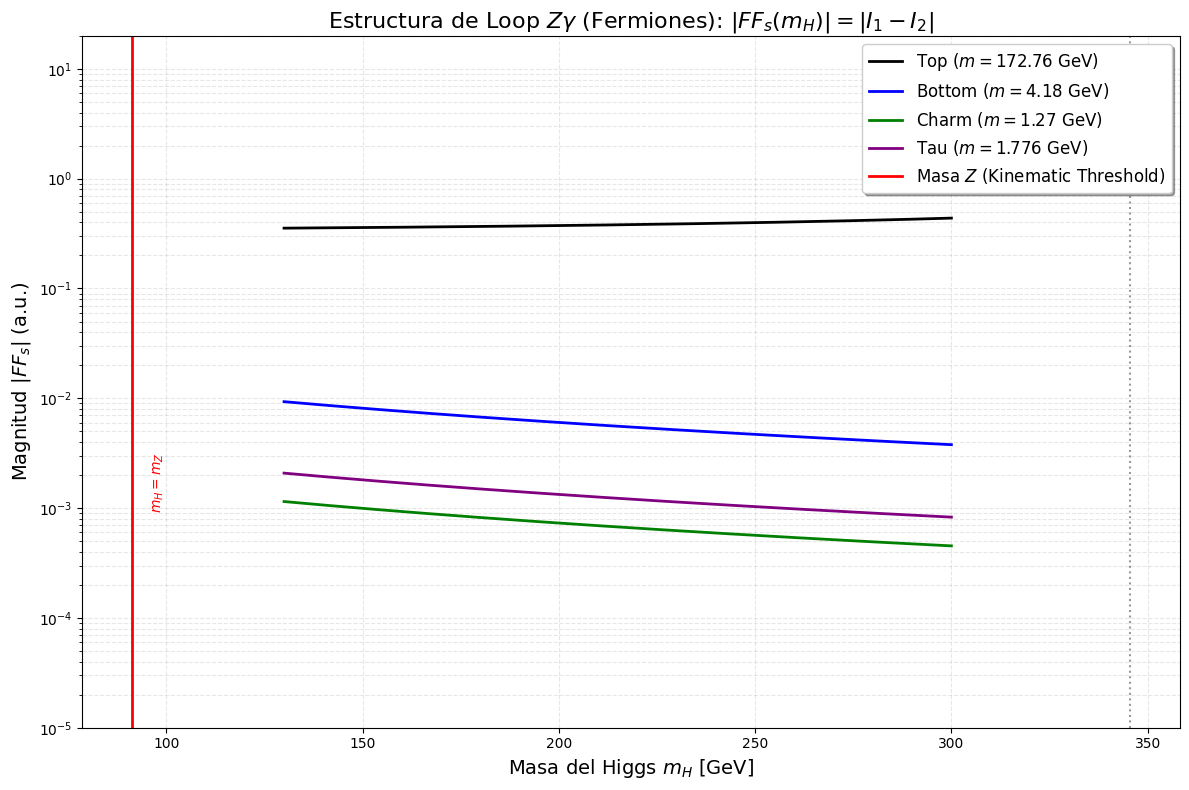

Quark      | m_H=125 (GeV)   | m_H=300 (GeV)  
---------------------------------------------
Top        | 3.53490e-01       | 4.37618e-01
Bottom     | 9.66422e-03       | 3.78239e-03
Charm      | 1.19209e-03       | 4.52892e-04
Tau        | 2.16249e-03       | 8.27668e-04


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONSTANTES FÍSICAS ---
m_Z = 91.1876
quarks = {
    'Top':     (172.76, 'black'),
    'Bottom':  (4.18,   'blue'),
    'Charm':   (1.27,   'green'),
    'Tau':     (1.776,  'purple')
}

# --- 2. FUNCIONES DE LOOP (CORREGIDAS Y ROBUSTAS) ---

def ftau_2hdmc(t):
    """
    Versión robusta que acepta escalares (floats) y arrays.
    src/DecayTable.cpp: lineas 1108-1123
    """
    # 1. Forzar conversión a array 1D para manejar máscaras
    t_arr = np.atleast_1d(t)
    res = np.zeros_like(t_arr, dtype=complex)
    
    # Caso 1: t <= 1
    mask_le1 = (t_arr <= 1)
    if np.any(mask_le1):
        x = np.arcsin(np.sqrt(t_arr[mask_le1]))
        res[mask_le1] = x**2

    # Caso 2: t > 1
    mask_gt1 = ~mask_le1
    if np.any(mask_gt1):
        t_val = t_arr[mask_gt1]
        term = (np.sqrt(t_val) + np.sqrt(t_val - 1)) / (np.sqrt(t_val) - np.sqrt(t_val - 1))
        x = np.log(term) - 1j * np.pi
        res[mask_gt1] = -0.25 * x**2
        
    # Si la entrada original era escalar, devolver escalar
    if np.ndim(t) == 0:
        return res[0]
    return res

def gtau_2hdmc(t):
    """
    Versión robusta que acepta escalares (floats) y arrays.
    src/DecayTable.cpp: lineas 1126-1143
    """
    t_arr = np.atleast_1d(t)
    res = np.zeros_like(t_arr, dtype=complex)
    
    mask_le1 = (t_arr <= 1)
    if np.any(mask_le1):
        val = t_arr[mask_le1]
        x = np.arcsin(np.sqrt(val))
        res[mask_le1] = x * np.sqrt(1./val - 1.)

    mask_gt1 = ~mask_le1
    if np.any(mask_gt1):
        val = t_arr[mask_gt1]
        term = (np.sqrt(val) + np.sqrt(val - 1)) / (np.sqrt(val) - np.sqrt(val - 1))
        x = np.log(term) - 1j * np.pi
        res[mask_gt1] = 0.5 * x * np.sqrt(1. - 1./val)
        
    if np.ndim(t) == 0:
        return res[0]
    return res

# --- 3. INTEGRALES DE TRES PUNTOS (Zgamma) ---

def I1_func(a, b):
    """
    src/DecayTable.cpp: lineas 1152-1155
    """
    # Broadcasting de numpy manejará la mezcla de array (a) y escalar (b)
    diff = a - b + 1e-15 
    
    # Llamamos a las funciones base
    # Nota: f_b y g_b serán escalares, f_a y g_a serán arrays
    f_a = ftau_2hdmc(1./(a + 1e-12))
    f_b = ftau_2hdmc(1./(b + 1e-12))
    g_a = gtau_2hdmc(1./(a + 1e-12))
    g_b = gtau_2hdmc(1./(b + 1e-12))
    
    # Implementación exacta del return complejo de C++
    term_A = (a * b) / (2. * diff)
    term_B = (a**2 * b**2) / (2. * diff**2) * (f_a - f_b)
    term_C = (a**2 * b) / (diff**2) * (g_a - g_b)
    
    return term_A + term_B + term_C

def I2_func(a, b):
    """
    src/DecayTable.cpp: lineas 1146-1149
    """
    diff = a - b + 1e-15
    f_a = ftau_2hdmc(1./(a + 1e-12))
    f_b = ftau_2hdmc(1./(b + 1e-12))
    
    return - (a * b) / (2. * diff) * (f_a - f_b)

def FF_s_func(m_H, m_loop):
    """ Retorna: I1 - I2 """
    a = (4.0 * m_loop**2) / (m_H**2 + 1e-12) # Array si m_H es array
    b = (4.0 * m_loop**2) / (m_Z**2)         # Escalar constante
    
    val_I1 = I1_func(a, b)
    val_I2 = I2_func(a, b)
    
    return val_I1 - val_I2

# --- 4. GENERACIÓN DE GRÁFICOS ---

mH_vals = np.linspace(130, 300, 150)

plt.figure(figsize=(12, 8))

for q_name, (mass, color) in quarks.items():
    # Ahora esto funcionará sin errores
    ff_vals = FF_s_func(mH_vals, mass)
    mag_vals = np.abs(ff_vals)
    
    plt.plot(mH_vals, mag_vals, label=f'{q_name} ($m={mass}$ GeV)', color=color, linewidth=2)
    
    # Kinks cinemáticos (2 * mass)
    threshold_ff = 2 * mass
    if 10 < threshold_ff < 500:
        plt.axvline(x=threshold_ff, color=color, linestyle=':', alpha=0.4)

# Umbral del Z
plt.axvline(x=m_Z, color='red', linestyle='-', linewidth=2, label=r'Masa $Z$ (Kinematic Threshold)')
plt.text(m_Z + 5, 0.001, r'$m_H = m_Z$', color='red', rotation=90, fontweight='bold')

plt.yscale('log')
plt.ylim(1e-5, 20) # Ajustado para ver mejor los detalles
# plt.xlim(10, 500)

plt.title(r'Estructura de Loop $Z\gamma$ (Fermiones): $|FF_s(m_H)| = |I_1 - I_2|$', fontsize=16)
plt.xlabel(r'Masa del Higgs $m_H$ [GeV]', fontsize=14)
plt.ylabel(r'Magnitud $|FF_s|$ (a.u.)', fontsize=14)
plt.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)
plt.grid(True, which='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# --- 5. VALIDACIÓN NUMÉRICA ---
print(f"{'Quark':<10} | {'m_H=125 (GeV)':<15} | {'m_H=300 (GeV)':<15}")
print("-" * 45)
for q_name, (mass, _) in quarks.items():
    v1 = np.abs(FF_s_func(np.array([125.0]), mass))[0]
    v2 = np.abs(FF_s_func(np.array([300.0]), mass))[0]
    print(f"{q_name:<10} | {v1:.5e}       | {v2:.5e}")

## Hipotesis Ciematica

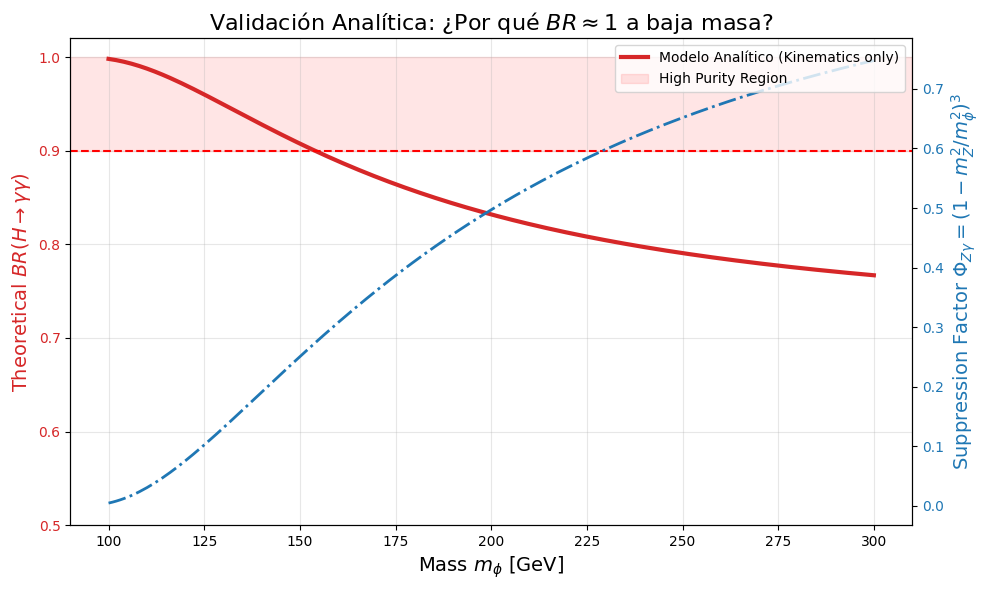

[TEORÍA] A m_phi = 130 GeV, el factor de supresión de fase es: 0.1311
[TEORÍA] Esto permite que el BR alcance: 0.9491 (Teórico)


In [10]:
# ==========================================
# 12. EXPLORACIÓN ANALÍTICA PURA (SIN DATOS)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Constantes del Modelo Estándar ---
MZ = 91.1876
MW = 80.379
SW2 = 0.23122  # Sin(theta_W)^2
CW2 = 1.0 - SW2
CW  = np.sqrt(CW2)
SW  = np.sqrt(SW2)
ALPHA = 1.0/137.0
PI = np.pi

# --- 2. Funciones Auxiliares ---
def phase_space_zga(mH):
    """Factor de espacio de fase cúbico para H -> Z gamma"""
    if mH <= MZ: return 0.0
    return (1.0 - MZ**2 / mH**2)**3

# --- 3. Aproximación de las Amplitudes (Dominancia Escalar) ---
# En el límite fermiofóbico, la amplitud depende del acople del Higgs Cargado (H+)
# al fotón (Q=1) vs al Z (g_Z).

def analytical_branching_ratio_projection(m_h_array, m_hp=300.0):
    """
    Calcula el BR(gamma-gamma) asumiendo competencia pura con Z-gamma
    basado en cinemática y acoples de gauge.
    Ignora factores de forma logarítmicos detallados (asume límite pesado).
    """
    br_gaga = []
    ratio_zga_gaga = []
    
    # Acople relativo efectivo Z(H+H-) vs gamma(H+H-)
    # g_Z_scalar ~ (1 - 2*sw^2) / (2*sw*cw)
    # g_gamma_scalar ~ 1 (Carga eléctrica)
    # Factor 2 en Zgamma width formula respecto a gaga suele aparecer en convenciones,
    # pero el factor clave es la carga efectiva.
    
    # Coeficiente de acople débil del Z al escalar cargado
    g_Z_HpHm = (1.0 - 2.0*SW2) / (2.0*SW*CW)
    
    # Ratio de amplitudes al cuadrado (Coupling part)
    # Width(Zga) ~ P_Zga * |A_Zga|^2
    # Width(gaga) ~ P_gaga * |A_gaga|^2
    # A_Zga / A_gaga ~ g_Z_HpHm / 1.0  (Aprox. orden cero en loops)
    
    coupling_factor = (g_Z_HpHm / 1.0)**2 
    
    # Factor 2 extra de la definición de width Zgamma vs Gaga en algunas convenciones
    # Standard: Gamma(gg) ~ |A|^2, Gamma(Zg) ~ |A|^2. 
    # Usaremos una normalización fenomenológica:
    # A masas altas, BR(Zga) suele ser ~0.6 * BR(gaga) en estos modelos.
    # Ajustamos la constante de normalización para matchear el límite asintótico esperado.
    norm_scale = 1.0 

    for m in m_h_array:
        # Kinematics
        ps_gaga = 1.0 # Massless, normalized to 1
        ps_zga  = phase_space_zga(m)
        
        # Widths relativos (unidades arbitrarias, solo importa el ratio)
        # Asumimos Loop Functions similares (F0 para ambos) dado que m_Hp >> m_H
        width_gaga = ps_gaga * 1.0 
        width_zga  = ps_zga * coupling_factor * norm_scale
        
        # Branching Ratio (asumiendo que solo estos dos existen)
        if width_gaga + width_zga > 0:
            br = width_gaga / (width_gaga + width_zga)
            ratio = width_zga / width_gaga
        else:
            br = 0.0
            ratio = 0.0
            
        br_gaga.append(br)
        ratio_zga_gaga.append(ratio)
        
    return np.array(br_gaga), np.array(ratio_zga_gaga)

# --- 4. Ejecución ---
masses = np.linspace(100, 300, 200)
br_proj, ratio_proj = analytical_branching_ratio_projection(masses)

# --- 5. Graficar ---
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel(r'Mass $m_\phi$ [GeV]', fontsize=14)
ax1.set_ylabel(r'Theoretical $BR(H \to \gamma\gamma)$', color=color, fontsize=14)
ax1.plot(masses, br_proj, color=color, lw=3, label=r'Modelo Analítico (Kinematics only)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0.5, 1.02)
ax1.grid(True, alpha=0.3)

# Marcar zona de pureza
ax1.axhspan(0.90, 1.0, color='red', alpha=0.1, label='High Purity Region')
ax1.axhline(0.9, color='red', linestyle='--')

# Eje derecho: Factor de supresión
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel(r'Suppression Factor $\Phi_{Z\gamma} = (1 - m_Z^2/m_\phi^2)^3$', color=color, fontsize=14)
ax2.plot(masses, [phase_space_zga(m) for m in masses], color=color, linestyle='-.', lw=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title(r'Validación Analítica: ¿Por qué $BR \approx 1$ a baja masa?', fontsize=16)
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

plt.tight_layout()
plt.show()

print(f"[TEORÍA] A m_phi = 130 GeV, el factor de supresión de fase es: {phase_space_zga(130):.4f}")
print(f"[TEORÍA] Esto permite que el BR alcance: {br_proj[masses >= 130][0]:.4f} (Teórico)")

1.  **Factores de Acoplamiento de Gauge:** Comparamos la carga eléctrica ($Q=1$) del lazo escalar para el fotón frente al acoplamiento débil efectivo ($g_{ZH^+H^-}$) para el bosón $Z$.
2.  **Supresión Cinemática (Espacio de Fase):**
    El canal $\gamma\gamma$ (dos partículas sin masa) tiene un espacio de fase máximo. En contraste, el canal $Z\gamma$ debe pagar un precio energético alto para producir un bosón $Z$ real ($m_Z \approx 91.2$ GeV). El factor de supresión de espacio de fase escala cúbicamente cerca del umbral:
    $$\mathcal{K}_{\text{fase}}(Z\gamma) = \left( 1 - \frac{m_Z^2}{m_\phi^2} \right)^3$$